* IMPORT NECESSARY LIBRARIES

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import sklearn 
from sklearn import metrics 
from services import outliers, num_isnull

%matplotlib inline

* Getting the dataset from UCI

In [3]:
from ucimlrepo import fetch_ucirepo 
  

heart_disease = fetch_ucirepo(id=45) 
  

X = heart_disease.data.features 
y = heart_disease.data.targets 
  
print(heart_disease.variables) 


        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None   
12      thal  Feature  Categorical        None   
13       num   Target      Integer        None   

                                          description  units missing_values  
0                                                None  years             no  
1                                                None   None             no  
2              

In [4]:
df = heart_disease.data.original

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [12]:
df.describe

<bound method NDFrame.describe of      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   1       145   233    1        2      150      0      2.3   
1     67    1   4       160   286    0        2      108      1      1.5   
2     67    1   4       120   229    0        2      129      1      2.6   
3     37    1   3       130   250    0        0      187      0      3.5   
4     41    0   2       130   204    0        2      172      0      1.4   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
297   57    0   4       140   241    0        0      123      1      0.2   
298   45    1   1       110   264    0        0      132      0      1.2   
299   68    1   4       144   193    1        0      141      0      3.4   
300   57    1   4       130   131    0        0      115      1      1.2   
301   57    0   2       130   236    0        2      174      0      0.0   

     slope   ca  thal  num  
0        3  0.0   6.0   

In [13]:
print ( '1-cp is chest pain from ' , df['cp'].min() , ' to ' , df['cp'].max() , 
      '\n2-trestbps is Resting Blood Pressure which its mean is ', df['trestbps'].mean(),
      '\n3-fbs is Fasting Blood Sugar which if value > 120 = 1 , else value = 0. Currency of it' , df['fbs'].value_counts(),
      '\n4-restecg is Resting ECG results'
      '\n5-exangexang (Exercise induced angina)'
      '\n6-oldpeakoldpeak (ST depression)'
      '\n7-slope (Slope of the peak exercise ST segment)'
      '\n8-ca is Number of vessels that appeared in the contrast X-ray (from 0 to 3)'
      '\n9- num is the diagnose from 0 to 4')


1-cp is chest pain from  1  to  4 
2-trestbps is Resting Blood Pressure which its mean is  130.0709219858156 
3-fbs is Fasting Blood Sugar which if value > 120 = 1 , else value = 0. Currency of it fbs
0    244
1     38
Name: count, dtype: int64 
4-restecg is Resting ECG results
5-exangexang (Exercise induced angina)
6-oldpeakoldpeak (ST depression)
7-slope (Slope of the peak exercise ST segment)
8-ca is Number of vessels that appeared in the contrast X-ray (from 0 to 3)
9- num is the diagnose from 0 to 4


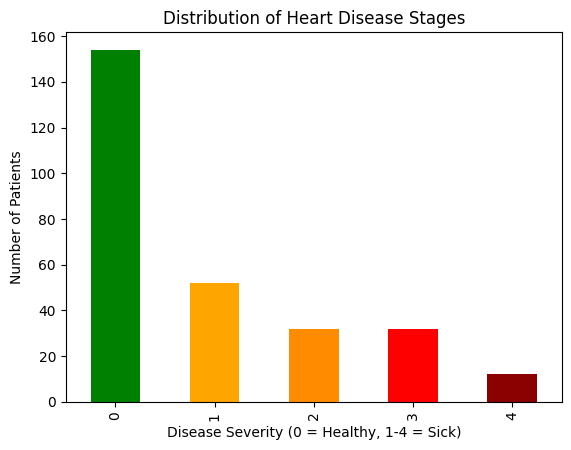

In [11]:
df['num'].value_counts().sort_index().plot(kind='bar', color=['green', 'orange', 'darkorange', 'red', 'darkred'])

plt.title('Distribution of Heart Disease Stages')
plt.xlabel('Disease Severity (0 = Healthy, 1-4 = Sick)')
plt.ylabel('Number of Patients')

plt.show()

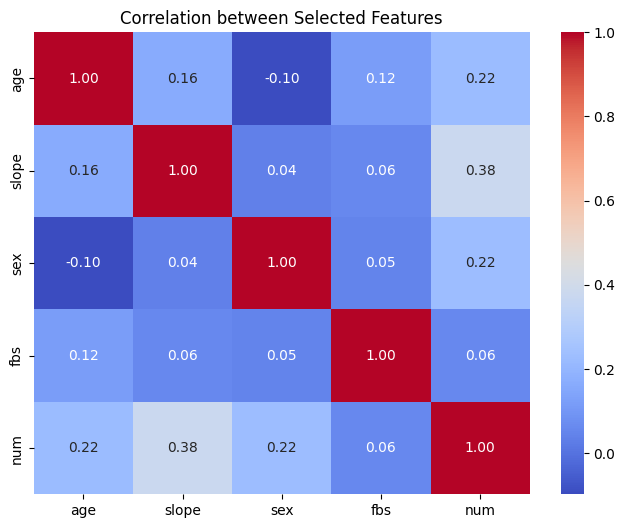

In [6]:
selected_features = ['age', 'slope', 'sex', 'fbs', 'num']

corr_matrix = df[selected_features].corr()

plt.figure(figsize=(8, 6)) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f") 


plt.title('Correlation between Selected Features')
plt.show()

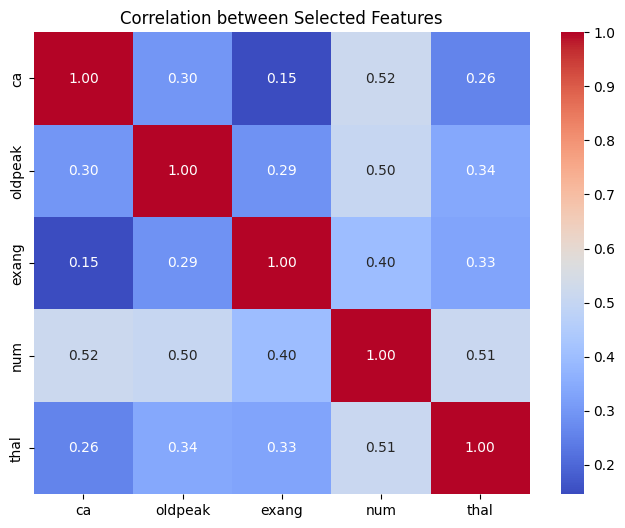

In [7]:
selected_features = ['ca', 'oldpeak', 'exang', 'num' , 'thal']

corr_matrix = df[selected_features].corr()

plt.figure(figsize=(8, 6)) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f") 


plt.title('Correlation between Selected Features')
plt.show()

* so the fretures our model will depend on is (slope , ca , oldpeak , thal)

In [8]:

print(num_isnull(df))

# as null values are small numbers of row so i chosse to drop them (C = 4 , THAL = 2 )

df.dropna(inplace=True)


print(num_isnull(df))

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [9]:
df = outliers(df , 'chol')
df = outliers (df , 'thalach')
df = outliers(df , 'trestbps')

Number of outliers in chol column was 5
Number of outliers in thalach column was 1
Number of outliers in trestbps column was 9
